# COGS 181 Final Project
## Using Grad-CAM to analyse various CNN representations on the Tiny ImageNet dataset.

#### Import necessary packages and functions.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import cv2
from tqdm.notebook import tqdm

from dataset import fix_val_folder, get_dataloaders, denormalise
from model   import build_model
from train   import run_training
from gradcam import GradCAM, GradCamPlusPlus, overlay_cam

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


#### Fix validation folder format, load data, and print out simple visualisations.

In [2]:
fix_val_folder("./tiny-imagenet-200/")
train_loader, val_loader, train_dataset, val_dataset = get_dataloaders("./tiny-imagenet-200/")
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Classes: {len(train_dataset.classes)}")

Moved 0 images into class subdirectories.
Train: 100,000 | Val: 10,000 | Classes: 200


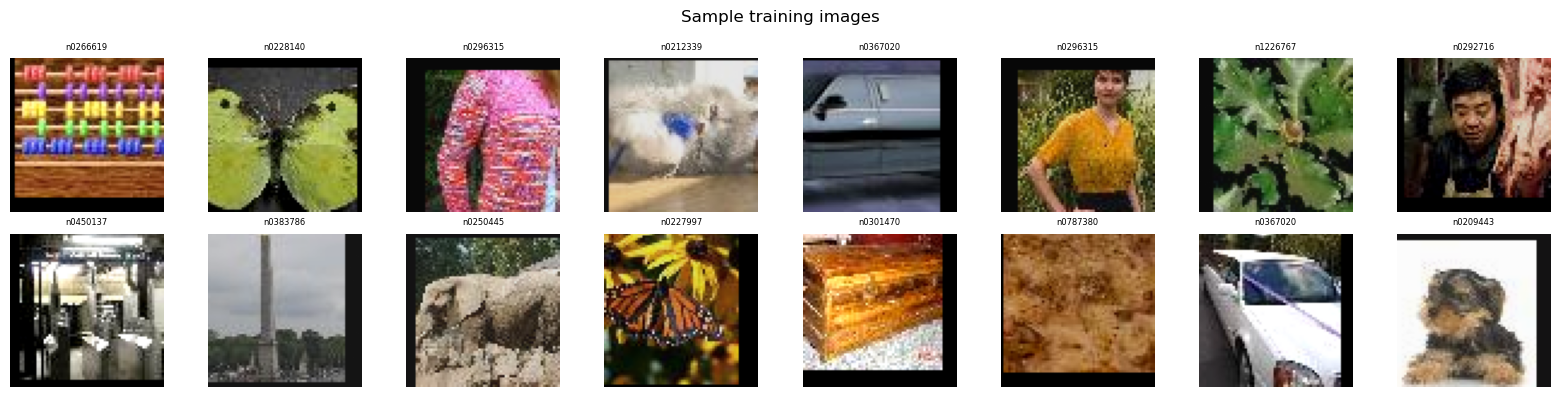

In [5]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = np.clip(denormalise(images[i]).permute(1, 2, 0).numpy(), 0, 1)
    ax.imshow(img)
    ax.set_title(train_dataset.classes[labels[i]][:8], fontsize=6)
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

#### Train baseline ResNet-18.
Note: I first set num_epochs to 3 to test pipeline, before running all 30 epochs.

In [10]:
model, history = run_training(train_loader, val_loader, save_name="baseline_resnet18", device=device)

Epoch [01/30]  Train Loss: 4.6598  Acc: 0.0560  |  Val Loss: 4.3943  Acc: 0.0866


Epoch [02/30]  Train Loss: 3.7898  Acc: 0.1598  |  Val Loss: 3.5881  Acc: 0.2012


Epoch [03/30]  Train Loss: 3.2492  Acc: 0.2486  |  Val Loss: 3.2480  Acc: 0.2679


Epoch [04/30]  Train Loss: 2.8743  Acc: 0.3224  |  Val Loss: 3.4419  Acc: 0.2678


Epoch [05/30]  Train Loss: 2.5989  Acc: 0.3765  |  Val Loss: 2.6843  Acc: 0.3733


...

Epoch [26/30]  Train Loss: 0.1355  Acc: 0.9748  |  Val Loss: 2.0827  Acc: 0.6025


Epoch [27/30]  Train Loss: 0.1129  Acc: 0.9812  |  Val Loss: 2.0783  Acc: 0.6040


Epoch [28/30]  Train Loss: 0.1010  Acc: 0.9846  |  Val Loss: 2.0892  Acc: 0.6043


Epoch [29/30]  Train Loss: 0.0941  Acc: 0.9864  |  Val Loss: 2.0831  Acc: 0.6054


Epoch [30/30]  Train Loss: 0.0913  Acc: 0.9872  |  Val Loss: 2.0843  Acc: 0.6059

Best Val Accuracy: 0.6059


#### Rebuild model using best checkpoint.
Note: Prevents having to rerun training each time the kernel is restarted.

In [7]:
from model import build_model

model = build_model(architecture='resnet18', norm='batch', dropout=0.0).to(device)
model.load_state_dict(torch.load('./checkpoints/best_baseline_resnet18.pth', map_location=device))
model.eval()
print('Model loaded from checkpoint.')

Model loaded from checkpoint.


#### Plot training curves.

NameError: name 'history' is not defined

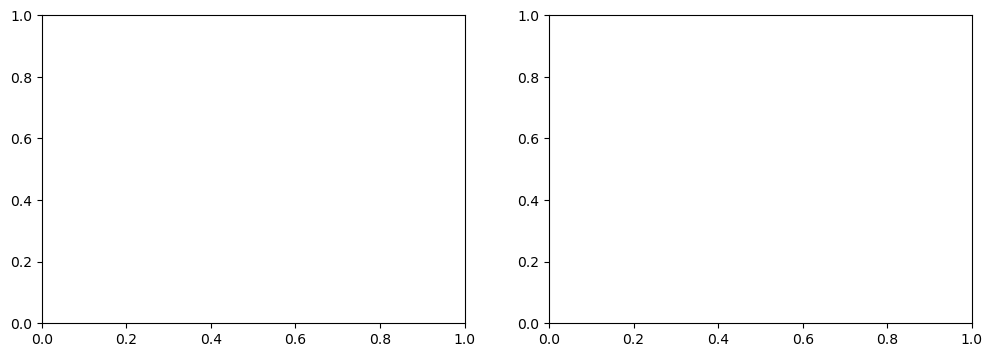

In [8]:
os.makedirs("./results", exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history["train_loss"]) + 1)
axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.suptitle("Baseline ResNet-18 Training Curves")
plt.tight_layout()
plt.savefig("./results/training_curves.png", dpi=150)
plt.show()

#### Function to convert image IDs to text.

In [3]:
def load_class_names(data_dir="./tiny-imagenet-200/"):
    id_to_name = {}
    with open(os.path.join(data_dir, 'words.txt')) as f:
        for line in f:
            parts = line.strip().split('\t')
            id_to_name[parts[0]] = parts[1].split(',')[0]  # take first name only
    return id_to_name

id_to_name = load_class_names()

#### Load the best checkpoint and begin Grad-CAM set up.
Note: checkpoints are saved since validation accuracy isn't always best at the last epoch. I used the final (fourth) layer to run GradCAM as it provides the best spatial information.

In [9]:
model.load_state_dict(torch.load("./checkpoints/best_baseline_resnet18.pth", map_location=device))
model.eval()

target_layer = model.layer4[-1].conv2
cam_extractor = GradCAM(model, target_layer)
cam_pp = GradCamPlusPlus(model, target_layer)

def get_val_samples(n=8):
    indices = np.random.choice(len(val_dataset), n, replace=False)
    tensors, names = [], []
    for idx in indices:
        image, label = val_dataset[idx]
        tensors.append(image.to(device))
        word_id = val_dataset.classes[label]
        names.append(id_to_name.get(word_id))
    return tensors, names

#### Visualisation 1: Grad-CAM batch. Shows whether the model is learning to localise objects meaningfully or just memorising.
Note: Depicts original, overlay, and heatmap for 8 validation images.

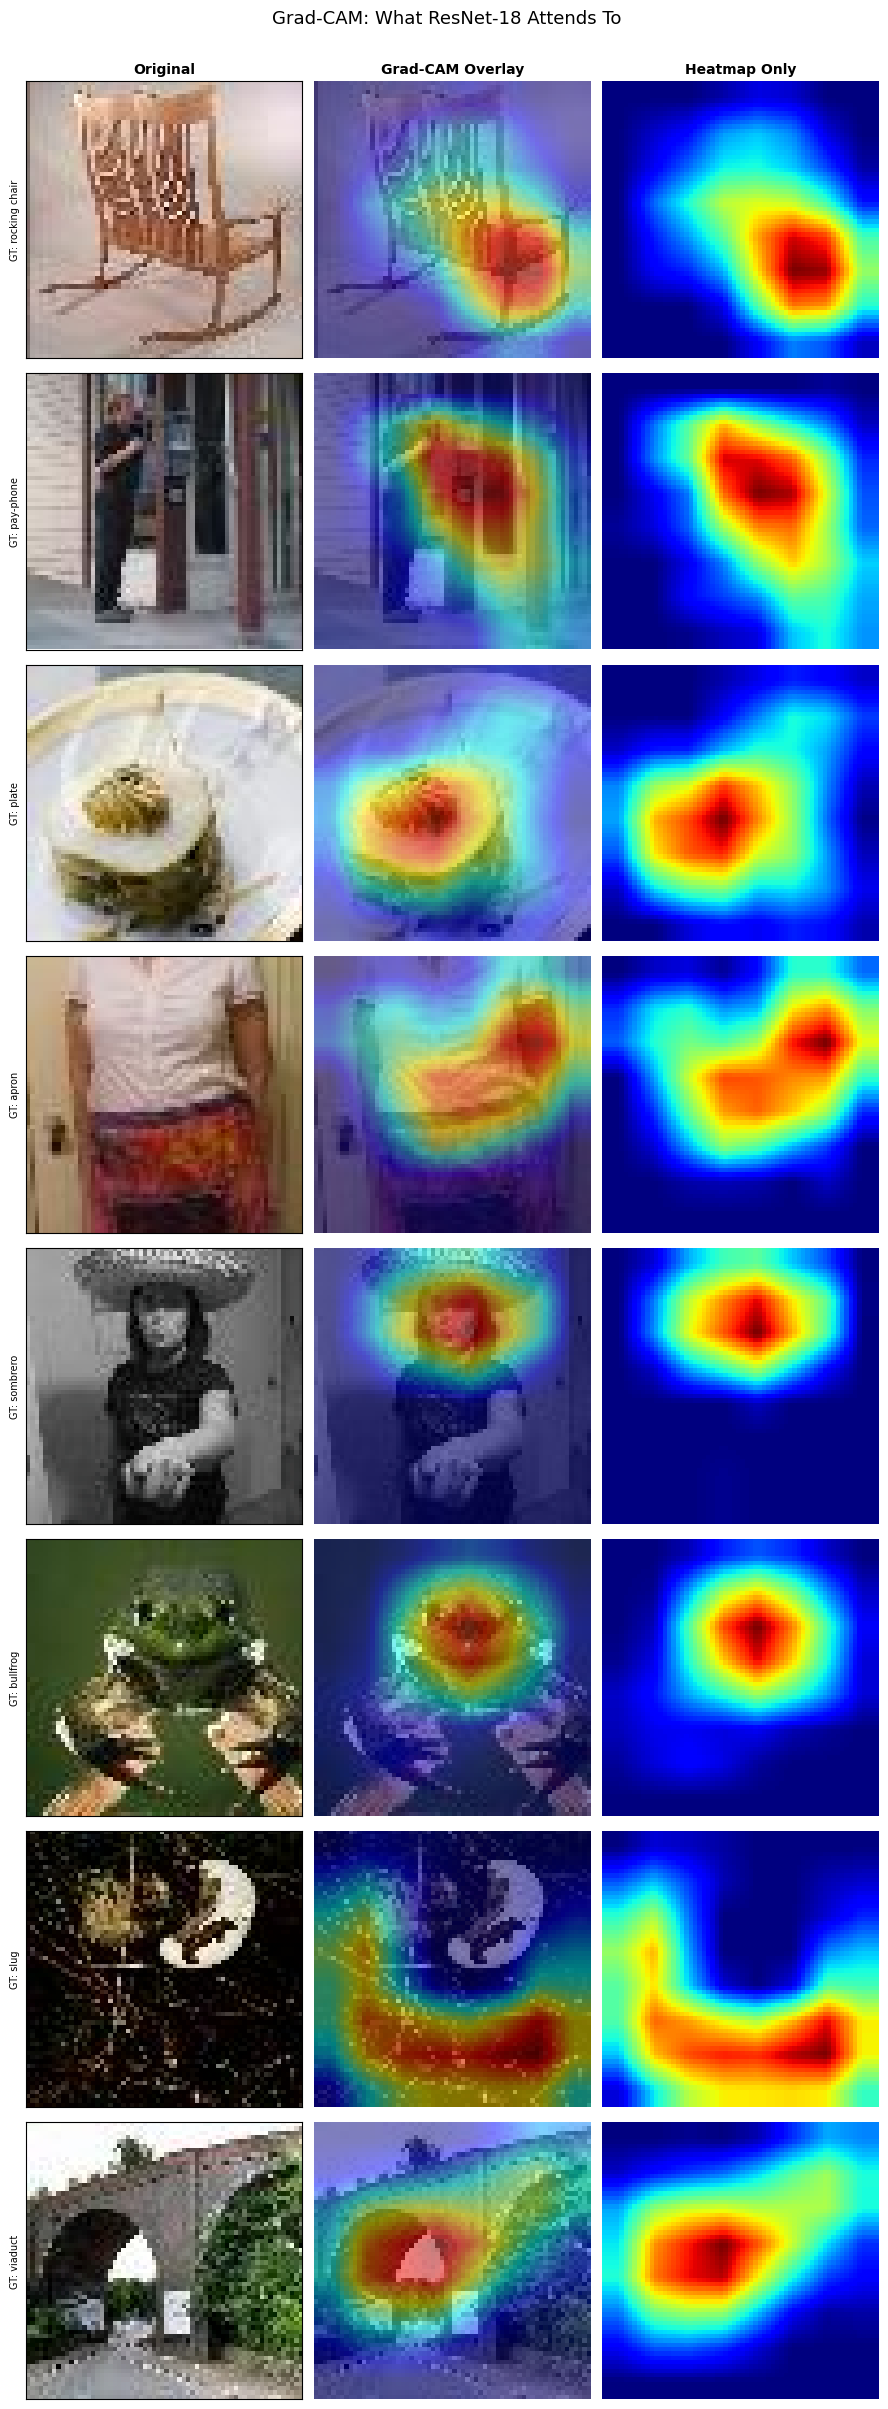

In [10]:
tensors, names = get_val_samples()

# Creats an 8x3 grid of 8 randomly sampled validation images
fig, axes = plt.subplots(8, 3, figsize=(9, 24))
for j, t in enumerate(["Original", "Grad-CAM Overlay", "Heatmap Only"]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(tensors, names)):
    cam, pred_idx = cam_extractor.generate(tensor.unsqueeze(0))
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_ylabel(f"GT: {name}", fontsize=7)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # Column 2
    # Grad-CAM overlay
    # Shows the heatmap overlayed with the actual image
    # Red regions show what the model was paying attention to during its prediction
    axes[i, 1].imshow(overlay_cam(img_uint8, cam))
    axes[i, 1].set_ylabel(f"Pred: {val_dataset.classes[pred_idx]}", fontsize=7)
    axes[i, 1].axis("off")

    # Column 3
    # Raw heatmap
    # Red = high attention, Green = medium attention, Blue = low attention
    axes[i, 2].imshow(cv2.resize(cam, (64, 64)), cmap="jet")
    axes[i, 2].axis("off")

plt.suptitle("Grad-CAM: What ResNet-18 Attends To", fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig("./results/gradcam_batch.png", dpi=150, bbox_inches="tight")
plt.show()

#### Visualisation 2: Grad-CAM vs Grad-CAM++

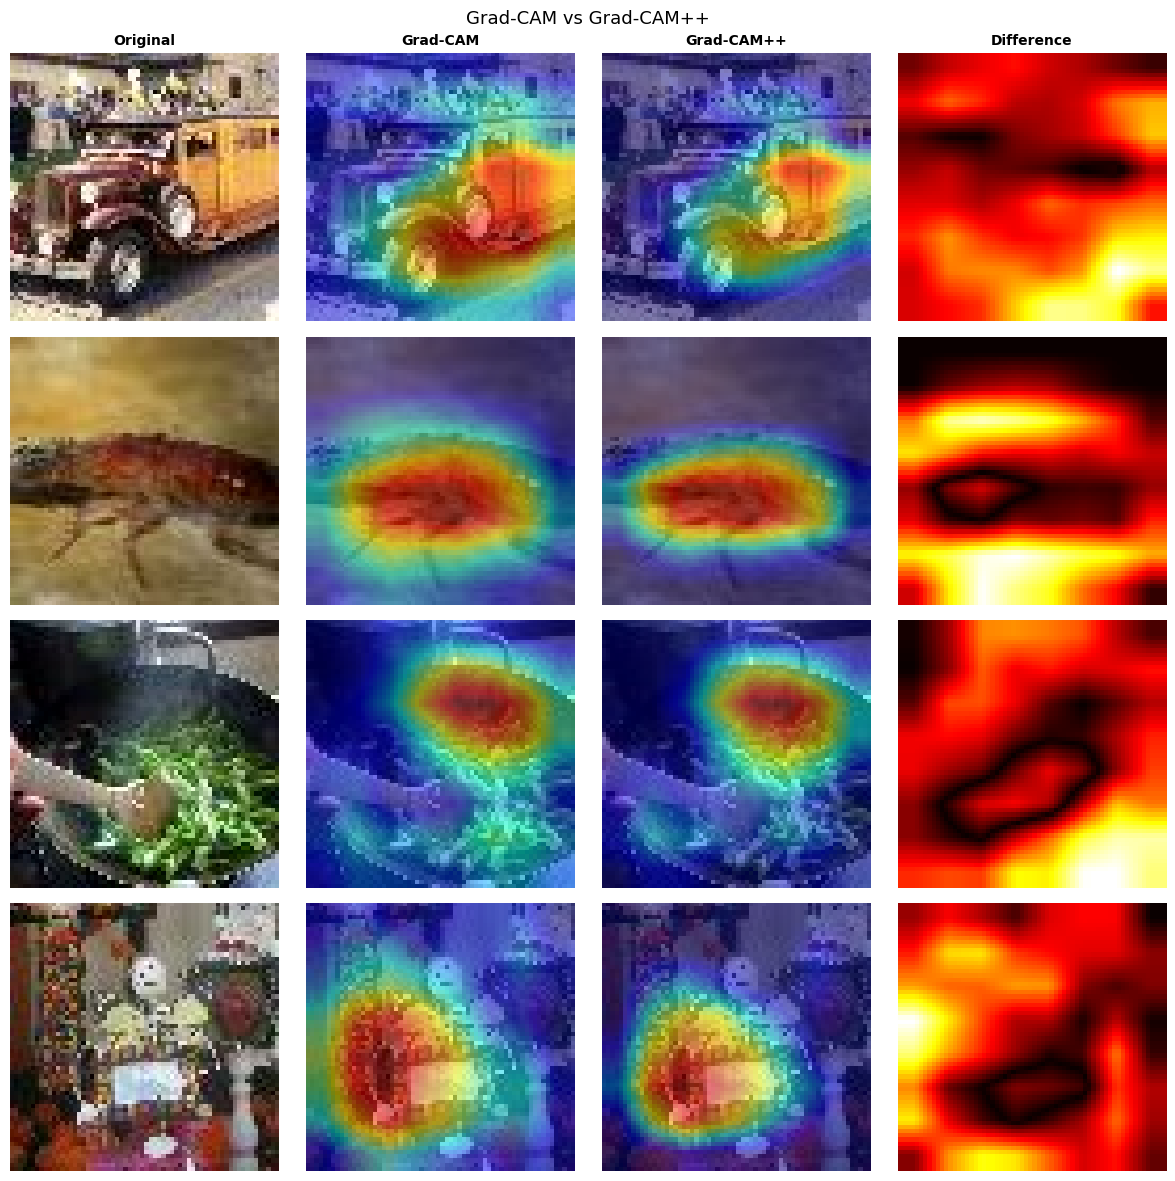

In [11]:
tensors_4, names_4 = get_val_samples(n=4)

# Creates a 4x4 grid of 4 randomly sampled validation images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for j, t in enumerate(["Original", "Grad-CAM", "Grad-CAM++", "Difference"]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(tensors_4, names_4)):
    cam1, _ = cam_extractor.generate(tensor.unsqueeze(0))
    cam2, _ = cam_pp.generate(tensor.unsqueeze(0))
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")
    diff = np.abs(cv2.resize(cam1, (64,64)) - cv2.resize(cam2, (64,64)))

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_ylabel(name, fontsize=7)
    axes[i, 0].axis("off")

    # Column 2
    # Grad-CAM overlay
    # Shows the heatmap overlayed with the actual image
    axes[i, 1].imshow(overlay_cam(img_uint8, cam1))
    axes[i, 1].axis("off")

    # Column 2
    # Grad-CAM++ overlay
    # Attention should be more tightly focused on the object itself
    axes[i, 2].imshow(overlay_cam(img_uint8, cam2))
    axes[i, 2].axis("off")

    # Column 4
    # Shows the absolute difference between both heatmaps
    # Brighter regions show where the two methods contrast
    axes[i, 3].imshow(diff, cmap="hot")
    axes[i, 3].axis("off")

plt.suptitle("Grad-CAM vs Grad-CAM++", fontsize=13)
plt.tight_layout()
plt.savefig("./results/gradcam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

#### Visualisation 3: Comparison of layer depths to show how attention changes from low-level to high-level features.
Note: Targets the final convolutional layer of each of ResNet's 4 residual blocks.

In [12]:
layers = [
    ("Layer 1 (Low)", model.layer1[-1].conv2),
    ("Layer 2", model.layer2[-1].conv2),
    ("Layer 3", model.layer3[-1].conv2),
    ("Layer 4 (High)", model.layer4[-1].conv2)
]

sample_tensors, sample_names = get_val_samples(n=3)

# Creates a 3x5 grid of 3 randomly sampled validation images
for j, t in enumerate(["Original"] + [n for n, _ in layers]):
    axes[0, j].set_title(t, fontsize=10, fontweight="bold")

for i, (tensor, name) in enumerate(zip(sample_tensors, sample_names)):
    img_np = np.clip(denormalise(tensor).permute(1,2,0).cpu().numpy(), 0, 1)
    img_uint8 = (img_np * 255).astype("uint8")

    # Column 1
    # Shows the raw image and the ground truth label
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_ylabel(name, fontsize=7)
    axes[i, 0].axis("off")

    # Columns 2-5
    # Shows Grad-CAM heatmap at each layer
    for j, (layer_name, layer) in enumerate(layers):
        cam, _ = GradCAM(model, layer).generate(tensor.unsqueeze(0))
        axes[i, j+1].imshow(overlay_cam(img_uint8, cam))
        axes[i, j+1].axis("off")

plt.suptitle("Grad-CAM Across Network Depth", fontsize=12)
plt.tight_layout()
plt.savefig("./results/layer_depth_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: index 4 is out of bounds for axis 1 with size 4

#### Ablation study: 
#### Run experiments by changing 4 parameters (Optimiser, LR Schedule, Normalisation, Dropout)
Note: Keep ResNet18 SGD Cosine BN as the baseline.

In [ ]:
ABLATION_EPOCHS = 10

EXPERIMENTS = [
    ("ResNet18 SGD Cosine BN", "resnet18", "sgd", "cosine", "batch", 0.0),
    ("ResNet18 Adam Cosine BN", "resnet18", "adam", "cosine", "batch", 0.0),
    ("ResNet18 AdamW Cosine BN", "resnet18", "adamw", "cosine", "batch", 0.0),
    ("ResNet18 SGD Step BN", "resnet18", "sgd", "step", "batch", 0.0),
    ("ResNet18 SGD Cosine GN", "resnet18", "sgd", "cosine", "group", 0.0),
    ("ResNet18 SGD Cosine LN", "resnet18", "sgd", "cosine", "layer", 0.0),
    ("ResNet18 DO0.3", "resnet18", "sgd", "cosine", "batch", 0.3),
    ("ResNet18 DO0.5", "resnet18", "sgd", "cosine", "batch", 0.5),
    ("ResNet34 SGD Cosine BN", "resnet34", "sgd", "cosine", "batch", 0.0),
    ("MobileNet SGD Cosine BN", "mobilenet", "sgd", "cosine", "batch", 0.0)
]

ablation_results = []
for name, arch, opt, schedule, norm, dropout in EXPERIMENTS:
    print(f"\n{"="*50}\n{name}\n{"="*50}")
    _, hist = run_training(train_loader, val_loader, architecture=arch, optimiser=opt, schedule=schedule,
                           norm=norm, dropout=dropout, num_epochs=ABLATION_EPOCHS, 
                           save_name=name.replace(" ", "_"), device=device)

    best = max(hist["val_acc"])
    ablation_results.append({
        "Experiment": name, "Architecture": arch, "Optimiser": opt,
        "Schedule": schedule, "Norm": norm,
        "Dropout": dropout, "Best Val Acc": round(best, 4)
    })
    print(f"-> {best:.4f}")

#### Display results.

In [ ]:
df = pd.DataFrame(ablation_results).sort_values("Best Val Acc", ascending=False)
df.to_csv("./results/ablation_summary.csv", index=False)
print(df[["Experiment", "Best Val Acc"]].to_string(index=False))

# Set baseline bars to red and everything else to blue to make comparisons
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df["Experiment"], df["Best Val Acc"], color=["coral"] + ["steelblue"] * (len(df) - 1))
ax.set_ylabel("Best Validation Accuracy")
ax.set_title("Ablation Study Results")
ax.set_xticks(df["Experiment"], rotation=35, ha="right", fontsize=7)
for bar, val in zip(bars, df["Best Val Acc"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f"{val:.3f}", 
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("./results/ablation_chart.png", dpi=150, bbox_inches="tight")
plt.show()